In [15]:
import networkx as nx
import itertools

In [ ]:
def three_profile(g: nx.Graph):
    """Computes the number of 3-node subgraphs that exists in a NetworkX Graph
    Assumes no loops.

    Returns a 4-tuple: (number of empty subgraphs, number of discs, number of wedges, number of triangles)
    """
    neighbor_sets = {}
    for v in g.nodes:
        neighbor_sets[v] = set(g.neighbors(v))

    triangle_counts = 0 # 3 edges
    wedge_counts = 0 # 2 edges
    disc_counts = 0 # 1 edge
    empty_counts = 0 # 0 edges
    
    for e in g.edges:
        u = e[0]
        v = e[1]
        num_u_neighbors = len(neighbor_sets[u])
        num_v_neighbors = len(neighbor_sets[v])
        num_common_neighbors = len(neighbor_sets[u].intersection(neighbor_sets[v]))

        triangle_counts += num_common_neighbors

        # to count wedges, split up wedges centered at u and centered at v
        # to count wedges centered at u containing uv, count all neighbors of u, except for v, and subtract common neighbors
        wedge_counts += num_u_neighbors - num_common_neighbors - 1 
        # to count wedges centered at v containing uv, count all neighbors of v, except for u, and subtract common neighbors
        wedge_counts += num_v_neighbors - num_common_neighbors - 1 # wedges centered at v containing uv
        
        # to get disc counts, number of nodes that aren't adjacent to u or v. |V(g)| - num of distinct neighbors of u union distinct neighbors of v
        # to calculate number of distinct neighbors, take both neighbor sets combined, and substract the common ones (they're counted twice)
        disc_counts += g.number_of_nodes() - num_u_neighbors - num_v_neighbors + num_common_neighbors 


    wedge_counts = wedge_counts / 2 # each wedge counted twice, once per edge in wedge
    triangle_counts = triangle_counts / 3 # each triangle counted thrice, once per edge in triangle
    empty_counts = (g.number_of_nodes() * (g.number_of_nodes() - 1) * (g.number_of_nodes() - 2) / 6) - triangle_counts - wedge_counts - disc_counts
    
    return empty_counts, disc_counts, wedge_counts, triangle_counts

In [12]:
def three_profile_slow(g: nx.Graph):
    # three_profile[i] is number of 3-subgraphs with i edges
    three_profile = {}
    three_profile[0] = 0
    three_profile[1] = 0
    three_profile[2] = 0
    three_profile[3] = 0
    
    for x,y,z in (itertools.combinations(g.nodes, 3)):
        num_edges = 0
        if g.has_edge(x,y):
            num_edges += 1
        if g.has_edge(x,z):
            num_edges += 1
        if g.has_edge(y,z):
            num_edges += 1
        three_profile[num_edges] += 1

    return three_profile
    

In [3]:
g = nx.Graph()
g.add_edge(1,2)
g.add_edge(2,3)
g.add_edge(3,4)
g.add_edge(1,4)
g.add_edge(1,3)

In [4]:
three_profile(g)

(2.0, 2.0, 0, 0.0)

In [18]:
gnp_1000 = nx.gnp_random_graph(1000, 0.3, seed=3)

In [19]:
three_profile_slow(gnp_1000)

{0: 57243490, 1: 73242197, 2: 31242820, 3: 4438493}

In [20]:
three_profile(gnp_1000)

(4438493.0, 31242820.0, 73242197, 57243490.0)

In [5]:
gnp = nx.gnp_random_graph(10000, 0.3, seed=None)

In [11]:
nx.write_edgelist(gnp, "gnp_10000.csv")

In [6]:
import time

start = time.time()
print(three_profile(gnp))
end = time.time()

print(end-start)

(4499297900.0, 31492974451.0, 73478668896, 57145728753.0)
1962.8992729187012


In [9]:
g_p = nx.petersen_graph()
three_profile(g_p)

(0.0, 30.0, 60, 30.0)

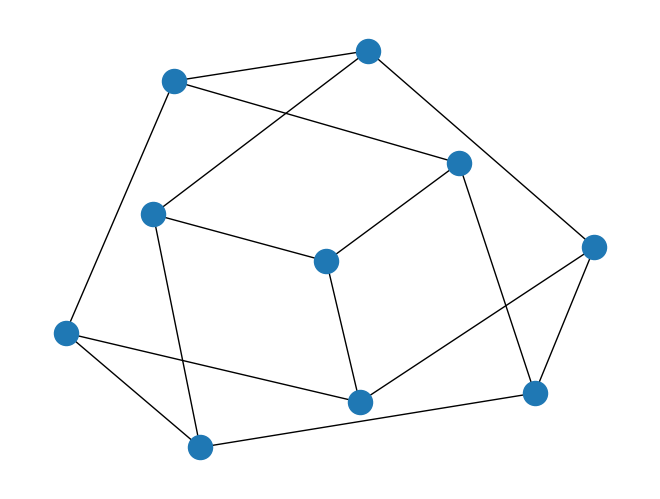

In [10]:
nx.draw(g_p)